# Cat vs Dog

`03_ANN_2couches.ipynb`

## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss
from tqdm import tqdm
import pickle

from utilities import load_data

# Fonctions

In [5]:
def initialisation(n0, n1, n2):

    W1 = np.random.randn(n1, n0)
    b1 = np.zeros((n1, 1))
    W2 = np.random.randn(n2, n1)
    b2 = np.zeros((n2, 1))

    parametres = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }

    return parametres

In [6]:
def forward_propagation(X, parametres):

    W1 = parametres['W1']
    b1 = parametres['b1']
    W2 = parametres['W2']
    b2 = parametres['b2']

    Z1 = W1.dot(X) + b1
    A1 = 1 / (1 + np.exp(-Z1))

    Z2 = W2.dot(A1) + b2
    A2 = 1 / (1 + np.exp(-Z2))

    activations = {
        'A1': A1,
        'A2': A2
    }

    return activations

In [7]:
def back_propagation(X, y, parametres, activations):

    A1 = activations['A1']
    A2 = activations['A2']
    W2 = parametres['W2']

    m = y.shape[1]

    dZ2 = A2 - y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims = True)

    dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims = True)

    gradients = {
        'dW1' : dW1,
        'db1' : db1,
        'dW2' : dW2,
        'db2' : db2
    }
    
    return gradients

In [8]:
def update(gradients, parametres, learning_rate):

    W1 = parametres['W1']
    b1 = parametres['b1']
    W2 = parametres['W2']
    b2 = parametres['b2']

    dW1 = gradients['dW1']
    db1 = gradients['db1']
    dW2 = gradients['dW2']
    db2 = gradients['db2']

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    parametres = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }

    return parametres

In [9]:
def predict(X, parametres):
  activations = forward_propagation(X, parametres)
  A2 = activations['A2']
  return A2 >= 0.5

In [10]:
def neural_network(X, y, X_test, y_test, n1=32, learning_rate=0.1, n_iter=1000):

    # initialisation parametres
    n0 = X.shape[0]
    n2 = y.shape[0]
    np.random.seed(0)
    parametres = initialisation(n0, n1, n2)

    train_loss = []
    train_acc = []
    test_acc = []

    # gradient descent
    for i in tqdm(range(n_iter)):
        activations = forward_propagation(X, parametres)
        A2 = activations['A2']

        # Plot courbe d'apprentissage
        train_loss.append(log_loss(y.flatten(), A2.flatten()))
        y_pred = predict(X, parametres)
        train_acc.append(accuracy_score(y.flatten(), y_pred.flatten()))
        test_acc.append(accuracy_score(y_test.flatten(), predict(X_test, parametres).flatten()))

        # mise a jour
        gradients = back_propagation(X, y, parametres, activations)
        parametres = update(gradients, parametres, learning_rate)


    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='train loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='train acc')
    plt.plot(test_acc, label='test acc')
    plt.legend()
    plt.show()

    print(f"final train acc: {train_acc[-1]:.3f} | final test acc: {test_acc[-1]:.3f}")

    return parametres

# Dataset

In [11]:
X_train, y_train, X_test, y_test = load_data()

print('raw shapes:', X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# normalize 0-255 -> 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# flatten 64x64 -> 4096, then transpose to (features, examples)
X_train = X_train.reshape(X_train.shape[0], -1).T
X_test = X_test.reshape(X_test.shape[0], -1).T

y_train = y_train.reshape(1, -1)
y_test = y_test.reshape(1, -1)

print('dimensions de X_train:', X_train.shape)
print('dimensions de y_train:', y_train.shape)

raw shapes: (1000, 64, 64) (1000, 1) (200, 64, 64) (200, 1)
dimensions de X_train: (4096, 1000)
dimensions de y_train: (1, 1000)


Sanity check — a few examples

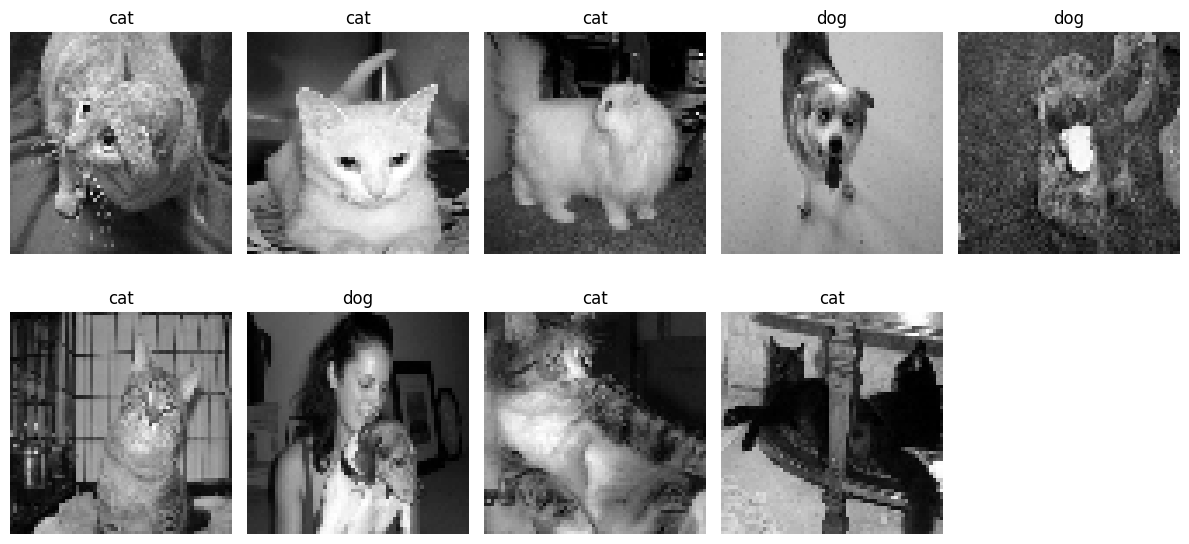

In [12]:
plt.figure(figsize=(12, 6))
for i in range(1, 10):
    plt.subplot(2, 5, i)
    plt.imshow(X_train[:, i].reshape(64, 64), cmap='gray')
    plt.title('dog' if y_train[0, i] == 1 else 'cat')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Train

100%|█████████████████████████████████████████████████| 3000/3000 [01:30<00:00, 32.98it/s]


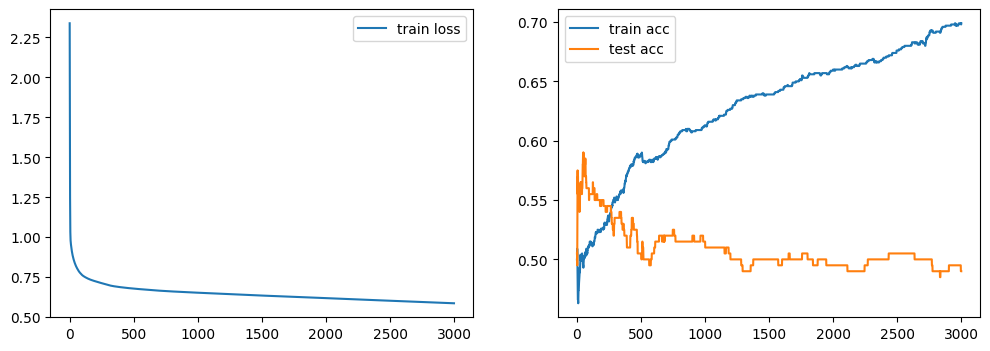

final train acc: 0.699 | final test acc: 0.490


In [13]:
parametres = neural_network(X_train, y_train, X_test, y_test, n1=32, learning_rate=0.1, n_iter=3000)

# Streamlit 

In [14]:
with open("catdog.pkl", "wb") as f:
    pickle.dump(parametres, f)

print("Fin")

Fin
